In [ ]:
# ─── Temel veri işleme kütüphaneleri ───────────────────────────────────────
import numpy as np          # Sayısal hesaplamalar (dizi işlemleri, lineer cebir)
import pandas as pd         # Tablo (DataFrame) yapısında veri işleme
import matplotlib.pyplot as plt  # Grafik çizimi
import seaborn as sns       # matplotlib üzerine kurulu, daha şık görselleştirme
import warnings
warnings.filterwarnings('ignore')  # Gereksiz uyarıları gizle

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.datasets import make_classification, load_breast_cancer
# load_breast_cancer : 569 örnek, 30 özellik içeren gerçek tıbbi veri seti

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
# train_test_split : veriyi eğitim / test olarak böler
# cross_val_score  : k-fold çapraz doğrulama skoru
# learning_curve   : farklı eğitim boyutlarında performans eğrisi

from sklearn.ensemble import AdaBoostClassifier
# AdaBoost sınıflandırıcı — sklearn içinde hazır gelir

from sklearn.tree import DecisionTreeClassifier
# AdaBoost'un zayıf öğrenicisi olarak kullanılacak karar ağacı

from sklearn.preprocessing import StandardScaler
# Özellikleri ortalaması 0, std'si 1 olacak şekilde ölçekler

from sklearn.metrics import (
    accuracy_score,         # Doğru tahmin oranı
    classification_report,  # Precision / Recall / F1 özet tablosu
    confusion_matrix,       # Hangi sınıf hangisiyle karıştırıldı?
    roc_auc_score,          # ROC eğrisinin altındaki alan (0.5=rastgele, 1=mükemmel)
    roc_curve,              # FPR ve TPR değerleri (ROC grafiği için)
    f1_score,               # Precision ve Recall'ın harmonik ortalaması
    precision_score,        # TP / (TP + FP) — "Tahmin ettiklerimin kaçı doğru?"
    recall_score            # TP / (TP + FN) — "Gerçeklerin kaçını yakaladım?"
)

import xgboost as xgb      # XGBoost kütüphanesi (pip install xgboost)
import time                 # Eğitim süresi ölçümü için

# ─── Görsel ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)      # Varsayılan grafik boyutu
plt.rcParams['font.size'] = 12                # Varsayılan yazı boyutu
plt.style.use('seaborn-v0_8-whitegrid')       # Beyaz ızgara temalı stil

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'   XGBoost versiyonu: {xgb.__version__}')

df = pd.read_csv('/content/heart_disease_uci.csv')

✅ Tüm kütüphaneler başarıyla yüklendi!
   XGBoost versiyonu: 3.3.0


In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
print("Sütun bazında eksik değer sayısı:")
print(df.isnull().sum())

print("\nToplam tekrar eden satır sayısı:", df.duplicated().sum())

Sütun bazında eksik değer sayısı:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Toplam tekrar eden satır sayısı: 0


In [ ]:
df['trestbps'] = df['trestbps'].fillna('Bilinmiyor')
df['chol'] = df['chol'].fillna('Bilinmiyor')
df['fbs'] = df['fbs'].fillna('Bilinmiyor')
df['restecg'] = df['restecg'].fillna('Bilinmiyor')
df['thalch'] = df['thalch'].fillna('Bilinmiyor')
df['exang'] = df['exang'].fillna('Bilinmiyor')
df['oldpeak'] = df['oldpeak'].fillna('Bilinmiyor')
df['slope'] = df['slope'].fillna('Bilinmiyor')
df['ca'] = df['ca'].fillna('Bilinmiyor')
df['thal'] = df['thal'].fillna('Bilinmiyor')

print("Doldurma sonrası eksik değer sayısı:\n", df.isnull().sum())
df.value_counts()

Doldurma sonrası eksik değer sayısı:
 id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


,,,,,,,,,,,,,,,,count
id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,
920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,Bilinmiyor,Bilinmiyor,Bilinmiyor,1,1
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,1
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,56,Male,Cleveland,non-anginal,130.0,256.0,True,lv hypertrophy,142.0,True,0.6,flat,1.0,fixed defect,2,1
12,56,Female,Cleveland,atypical angina,140.0,294.0,False,lv hypertrophy,153.0,False,1.3,flat,0.0,normal,0,1
11,57,Male,Cleveland,asymptomatic,140.0,192.0,False,normal,148.0,False,0.4,flat,0.0,fixed defect,0,1


In [ ]:


# Create a copy of the DataFrame to perform preprocessing
processed_df = df.copy()

# 1. Handle 'Bilinmiyor' and convert to numeric for columns that should be float
numeric_cols_with_bilinmiyor = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numeric_cols_with_bilinmiyor:
    processed_df[col] = processed_df[col].replace('Bilinmiyor', np.nan)
    processed_df[col] = pd.to_numeric(processed_df[col]) # Ensure conversion to numeric
    processed_df[col].fillna(processed_df[col].mean(), inplace=True) # Impute with mean

# 2. Handle boolean-like columns 'fbs' and 'exang'
bool_like_cols = ['fbs', 'exang']
for col in bool_like_cols:
    # Replace 'True'/'False' with 1/0, and 'Bilinmiyor' with NaN
    processed_df[col] = processed_df[col].replace({'True': 1, 'False': 0, 'Bilinmiyor': np.nan})
    processed_df[col] = pd.to_numeric(processed_df[col]) # Ensure conversion to numeric
    processed_df[col].fillna(processed_df[col].mode()[0], inplace=True) # Impute with mode

# 3. Handle categorical columns that had 'Bilinmiyor' by treating 'Bilinmiyor' as a new category
categorical_cols_with_bilinmiyor = ['restecg', 'slope', 'thal']
for col in categorical_cols_with_bilinmiyor:
    processed_df[col] = processed_df[col].replace('Bilinmiyor', 'Unknown')
    # Fill any remaining NaNs in these columns with mode, assuming they should be strings for get_dummies
    processed_df[col].fillna(processed_df[col].mode()[0], inplace=True)

# 4. Convert the target variable 'num' to binary (0 for not sick, 1 for sick)
# This aligns with previous visualizations and binary classification metrics
processed_df['num_binary'] = (processed_df['num'] != 0).astype(int)

# 5. Drop the original 'num' and 'id' columns as they are either processed or not features
processed_df.drop(['num', 'id'], axis=1, inplace=True)

# 6. One-hot encode all remaining categorical (object) columns
# pd.get_dummies will automatically select object and categorical dtypes
processed_df = pd.get_dummies(processed_df, drop_first=True) # drop_first to avoid multicollinearity

print("Processed DataFrame Info:")
processed_df.info()

print("\nFirst 5 rows of the processed DataFrame:")
print(processed_df.head())

# Assign features (X) and target (y) from the processed_df
X_processed = processed_df.drop('num_binary', axis=1)
y_processed = processed_df['num_binary']

print("\nShape of X_processed:", X_processed.shape)
print("Shape of y_processed:", y_processed.shape)

Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    float64
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    float64
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   num_binary                920 non-null    int64  
 9   sex_Male                  920 non-null    bool   
 10  dataset_Hungary           920 non-null    bool   
 11  dataset_Switzerland       920 non-null    bool   
 12  dataset_VA Long Beach     920 non-null    bool   
 13  cp_atypical angina        920 non-null 

In [ ]:
x = df.drop(['num', 'id'], axis=1)
y = df['num']

print("Veri Seti Bilgileri")
print("-"*55)
print(f"Özellik sayısı: {x.shape[1]}")
print(f"Örnek sayısı: {x.shape[0]}")
print(f"Sınıf dağılımı: {dict(y.value_counts())}")
print(f" 0 = Hasta değil: {sum(y==0)}")
print(f" 1,2,3,4 = Hasta olabilir: {sum(y != 0)}")


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim seti: {x_train.shape[0]} örnek")
print(f"Test seti: {x_test.shape[0]} örnek")

x.head()

Veri Seti Bilgileri
-------------------------------------------------------
Özellik sayısı: 14
Örnek sayısı: 920
Sınıf dağılımı: {0: np.int64(411), 1: np.int64(265), 2: np.int64(109), 3: np.int64(107), 4: np.int64(28)}
 0 = Hasta değil: 411
 1,2,3,4 = Hasta olabilir: 509
Eğitim seti: 736 örnek
Test seti: 184 örnek


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


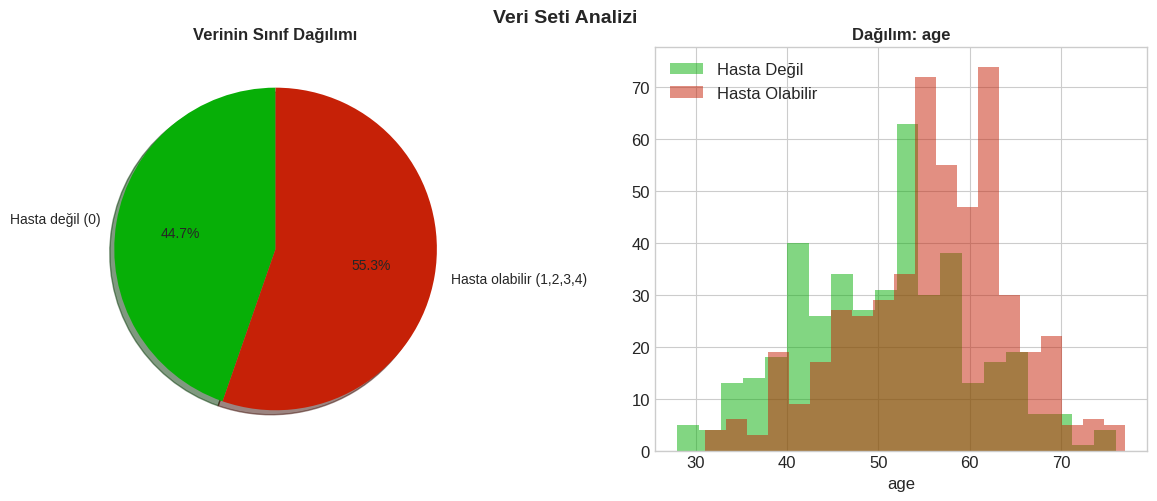

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_not_sick = sum(y == 0)
counts_sick = sum(y != 0)

pie_data = [counts_not_sick, counts_sick]
pie_labels = ['Hasta değil (0)', 'Hasta olabilir (1,2,3,4)']
pie_colors = ['#07af07', '#c62107']

axes[0].pie(pie_data, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', startangle=90, shadow=True, textprops={'fontsize': 10})
axes[0].set_title('Verinin Sınıf Dağılımı', fontsize=12, fontweight='bold')


features_to_plot = x.columns
first_feature = features_to_plot[0]


axes[1].hist(x[first_feature][y==0], alpha=0.5, label='Hasta Değil', color='#07af07', bins=20)
axes[1].hist(x[first_feature][y!=0], alpha=0.5, label='Hasta Olabilir', color='#c62107', bins=20)

axes[1].set_title(f"Dağılım: {first_feature}", fontsize=12, fontweight='bold')
axes[1].set_xlabel(first_feature)
axes[1].legend()

plt.tight_layout()
plt.suptitle('Veri Seti Analizi', fontsize=14, fontweight='bold', y=1.0)
plt.show()

**ADABOOST MODELİ**

In [ ]:


print("ADABOOST MODELİ")
print("-"*55)


x_train, x_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)

start = time.time()

ada_model.fit(x_train, y_train)

ada_time = time.time() - start

ada_pred = ada_model.predict(x_test)


ada_prob = ada_model.predict_proba(x_test)[:,1]

ada_acc = accuracy_score(y_test, ada_pred)
ada_auc = roc_auc_score(y_test, ada_prob)
ada_f1 = f1_score(y_test, ada_pred)
ada_prec = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)

print(f"Eğitim Süresi: {ada_time:.4f} sn")
print(f"Doğruluk: {ada_acc:.4f} ({ada_acc*100:.2f}%)")
print(f"AUC-ROC: {ada_auc:.4f}")
print(f"F1: {ada_f1:.4f}")
print(f"Precission: {ada_prec:.4f}")
print(f"Recall: {ada_recall:.4f}")
print("-"*55)
print("Detaylı Rapor: ")
# Adjust target_names for binary classification (0: Hasta değil, 1: Hasta olabilir)
print(classification_report(y_test, ada_pred, target_names=['Hasta değil', 'Hasta olabilir']))

ADABOOST MODELİ
-------------------------------------------------------
Eğitim Süresi: 0.7686 sn
Doğruluk: 0.8478 (84.78%)
AUC-ROC: 0.9128
F1: 0.8667
Precission: 0.8426
Recall: 0.8922
-------------------------------------------------------
Detaylı Rapor: 
                precision    recall  f1-score   support

   Hasta değil       0.86      0.79      0.82        82
Hasta olabilir       0.84      0.89      0.87       102

      accuracy                           0.85       184
     macro avg       0.85      0.84      0.84       184
  weighted avg       0.85      0.85      0.85       184



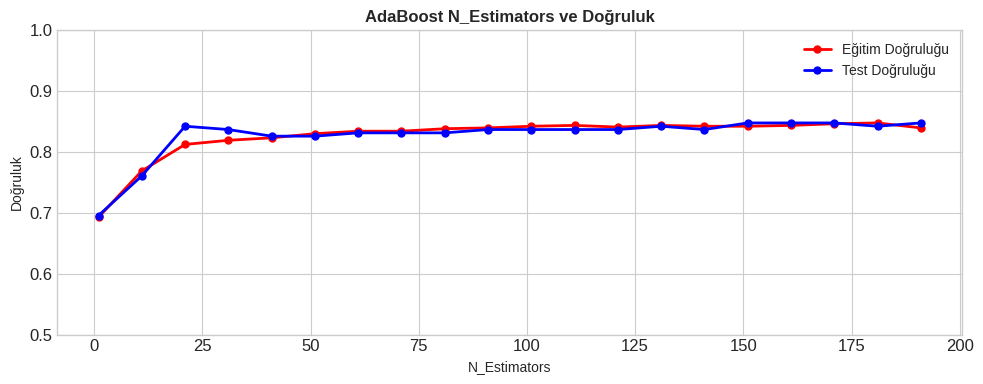

In [ ]:
n_estimators_range = range(1, 201, 10)
ada_train_scores = []
ada_test_scores = []

for n in n_estimators_range:
  m = AdaBoostClassifier(
      estimator=DecisionTreeClassifier(max_depth=1),
      n_estimators=n,
      learning_rate=0.1,
      algorithm='SAMME',
      random_state=42
  )
  m.fit(x_train, y_train)
  ada_train_scores.append(accuracy_score(y_train, m.predict(x_train)))
  ada_test_scores.append(accuracy_score(y_test, m.predict(x_test)))

plt.figure(figsize=(10,4))


plt.plot(list(n_estimators_range), ada_train_scores, 'r-o', label='Eğitim Doğruluğu', markersize=5, linewidth=2)
plt.plot(list(n_estimators_range), ada_test_scores, 'b-o', label='Test Doğruluğu', markersize=5, linewidth=2)

plt.xlabel('N_Estimators', fontsize=10)
plt.ylabel('Doğruluk', fontsize=10)
plt.title('AdaBoost N_Estimators ve Doğruluk', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

**XG BOOST MODELİ**

In [ ]:
print("XG BOOST MODELİ")
print("-"*55)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

start = time.time()
xgb_model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)[:,1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)

print(f"Eğitim Süresi: {xgb_time:.4f} sn")
print(f"Doğruluk     : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print(f"AUC-ROC      : {xgb_auc:.4f}")
print(f"F1           : {xgb_f1:.4f}")
print(f"Precission   : {xgb_prec:.4f}")
print(f"Recall       : {xgb_recall:.4f}")
print("-"*55)
print("Detaylı Rapor: ")
print(classification_report(y_test, xgb_pred, target_names=['Hasta Değil', 'Hasta Olabilir']))

XG BOOST MODELİ
-------------------------------------------------------
Eğitim Süresi: 0.2990 sn
Doğruluk     : 0.8478 (84.78%)
AUC-ROC      : 0.9232
F1           : 0.8667
Precission   : 0.8426
Recall       : 0.8922
-------------------------------------------------------
Detaylı Rapor: 
                precision    recall  f1-score   support

   Hasta Değil       0.86      0.79      0.82        82
Hasta Olabilir       0.84      0.89      0.87       102

      accuracy                           0.85       184
     macro avg       0.85      0.84      0.84       184
  weighted avg       0.85      0.85      0.85       184



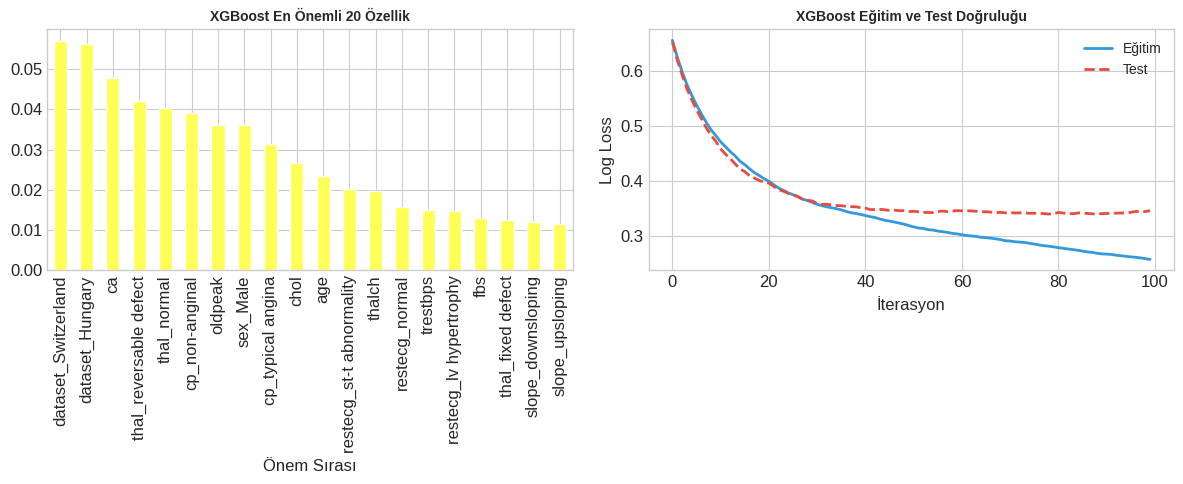

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

feat_importance = pd.Series(
    xgb_model.feature_importances_, index = X_processed.columns).sort_values(ascending=False).tail(20)

feat_importance.plot(kind='bar', ax=axes[0], color='#ffff56', edgecolor='white')
axes[0].set_title("XGBoost En Önemli 20 Özellik", fontsize=10, fontweight='bold')
axes[0].set_xlabel('Önem Sırası')

results = xgb_model.evals_result()

axes[1].plot(results['validation_0']['logloss'],
             label='Eğitim', color='#3498db', linewidth=2)
axes[1].plot(results['validation_1']['logloss'],
             label='Test', color='#e74c3c', linewidth=2, linestyle='--')

axes[1].set_title("XGBoost Eğitim ve Test Doğruluğu", fontsize=10, fontweight='bold')
axes[1].set_xlabel('İterasyon')
axes[1].set_ylabel('Log Loss')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

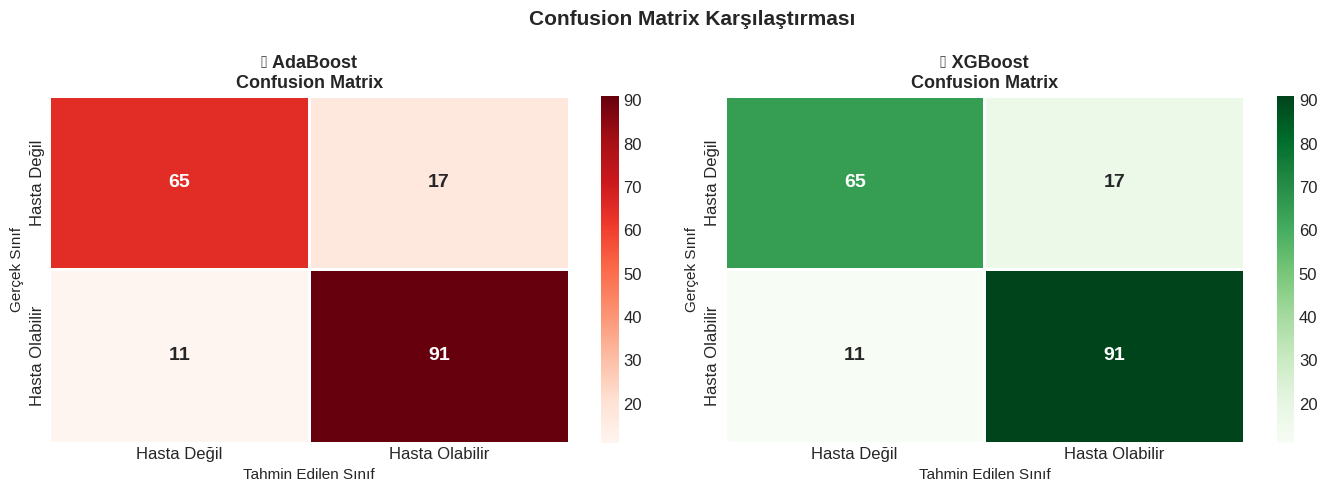

In [ ]:
# ─── Confusion Matrix Karşılaştırması ───────────────────────────────────────
# Confusion Matrix: tahmin edilen sınıf vs gerçek sınıf tablosu.
#   - Diagonal (sol-üst, sağ-alt): doğru tahminler (TP ve TN)
#   - Diagonal dışı: yanlış tahminler (FP ve FN)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zip() ile iki modelin verisi aynı anda işleniyor
for ax, pred, title, color in zip(
    axes,
    [ada_pred, xgb_pred],
    ['🔴 AdaBoost', '🟢 XGBoost'],
    ['Reds', 'Greens']
):
    cm = confusion_matrix(y_test, pred)



    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        ax=ax,
        xticklabels=['Hasta Değil', 'Hasta Olabilir'],
        yticklabels=['Hasta Değil', 'Hasta Olabilir'],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Gerçek Sınıf', fontsize=11)
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

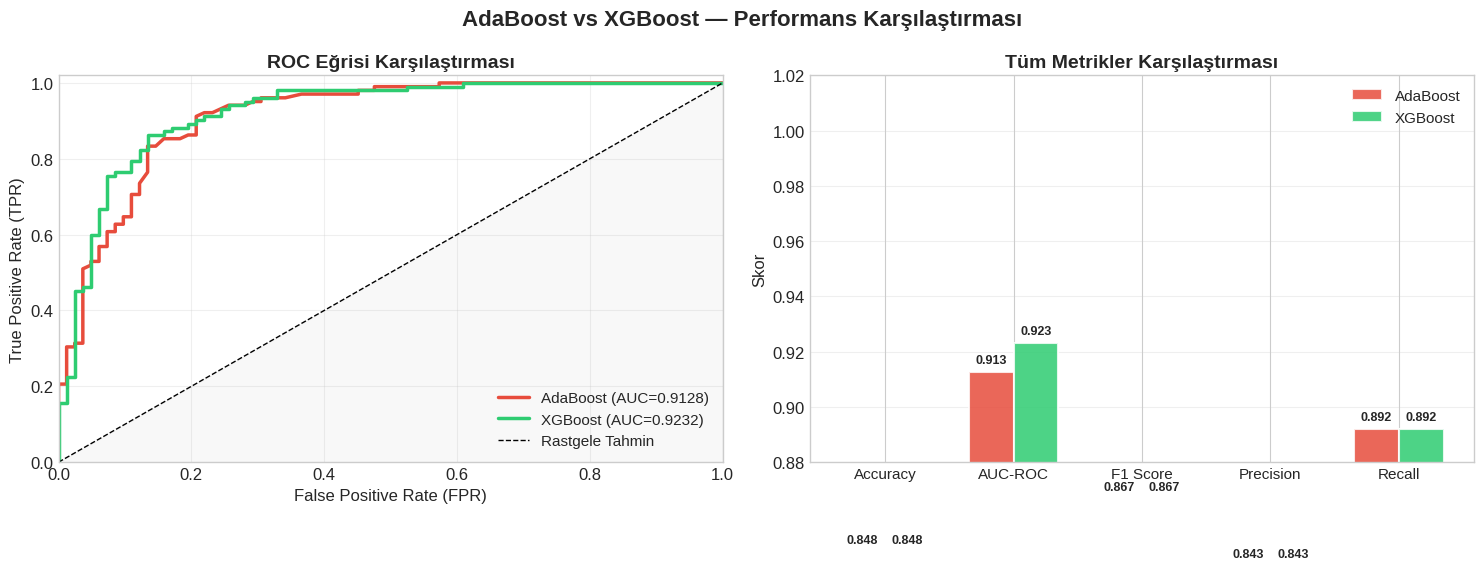

In [ ]:
# ROC Eğrisi + Metrik Bar Grafiği
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: ROC Eğrisi
for prob, label, color, acc, auc in [
    (ada_prob, 'AdaBoost', '#e74c3c', ada_acc, ada_auc),
    (xgb_prob, 'XGBoost',  '#2ecc71', xgb_acc, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)

    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{label} (AUC={auc:.4f})')


axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Sağ Taraf: Metrik Bar Grafiği
metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
ada_scores = [ada_acc, ada_auc, ada_f1, ada_prec, ada_recall]
xgb_scores = [xgb_acc, xgb_auc, xgb_f1, xgb_prec, xgb_recall]

x = np.arange(len(metrics))
width = 0.35


bars1 = axes[1].bar(x - width/2, ada_scores, width, label='AdaBoost',
                     color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, xgb_scores, width, label='XGBoost',
                     color='#2ecc71', alpha=0.85, edgecolor='white', linewidth=1.5)


for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Skor', fontsize=12)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0.88, 1.02)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('AdaBoost vs XGBoost — Performans Karşılaştırması',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

🔄 5-Fold Cross Validation Yapılıyor...
-------------------------------------------------------
🔴 AdaBoost  CV Scores: [0.8207 0.625  0.9348 0.8587 0.6739]
   Ortalama: 0.7826 ± 0.1158

🟢 XGBoost   CV Scores: [0.7989 0.6413 0.837  0.7935 0.625 ]
   Ortalama: 0.7391 ± 0.0880


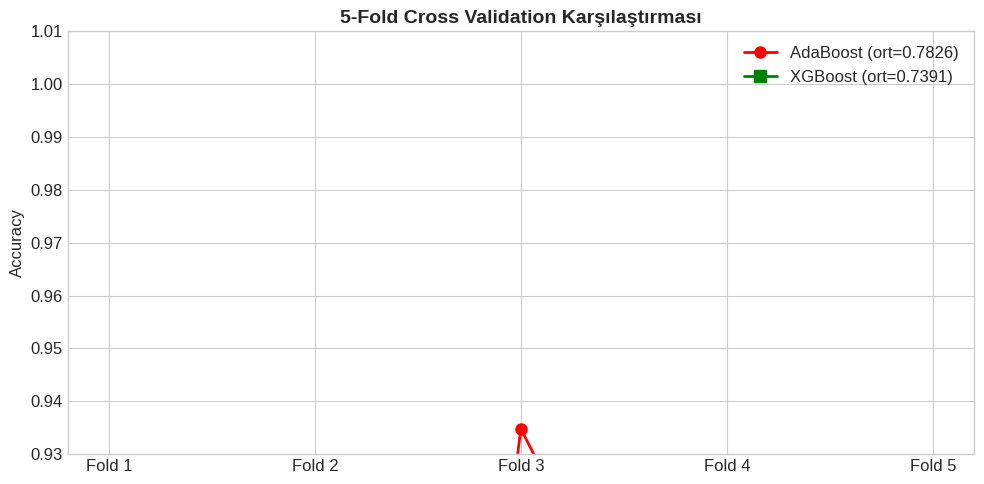

In [ ]:
# 5-Fold Cross Validation

print('🔄 5-Fold Cross Validation Yapılıyor...')
print('-'*55)

ada_cv = cross_val_score(ada_model, X_processed, y_processed, cv=5, scoring='accuracy')


xgb_cv = cross_val_score(xgb_model, X_processed, y_processed, cv=5, scoring='accuracy')

print(f'🔴 AdaBoost  CV Scores: {ada_cv.round(4)}')
print(f'   Ortalama: {ada_cv.mean():.4f} \u00b1 {ada_cv.std():.4f}')

print()
print(f'🟢 XGBoost   CV Scores: {xgb_cv.round(4)}')
print(f'   Ortalama: {xgb_cv.mean():.4f} \u00b1 {xgb_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)

ax.plot(x, ada_cv, 'r-o', markersize=8, linewidth=2,
        label=f'AdaBoost (ort={ada_cv.mean():.4f})')
ax.plot(x, xgb_cv, 'g-s', markersize=8, linewidth=2,
        label=f'XGBoost (ort={xgb_cv.mean():.4f})')

ax.fill_between(x,
                ada_cv.mean() - ada_cv.std(),
                ada_cv.mean() + ada_cv.std(),
                alpha=0.1, color='red')
ax.fill_between(x,
                xgb_cv.mean() - xgb_cv.std(),
                xgb_cv.mean() + xgb_cv.std(),
                alpha=0.1, color='green')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross Validation Karşılaştırması', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.93, 1.01)
plt.tight_layout()
plt.show()

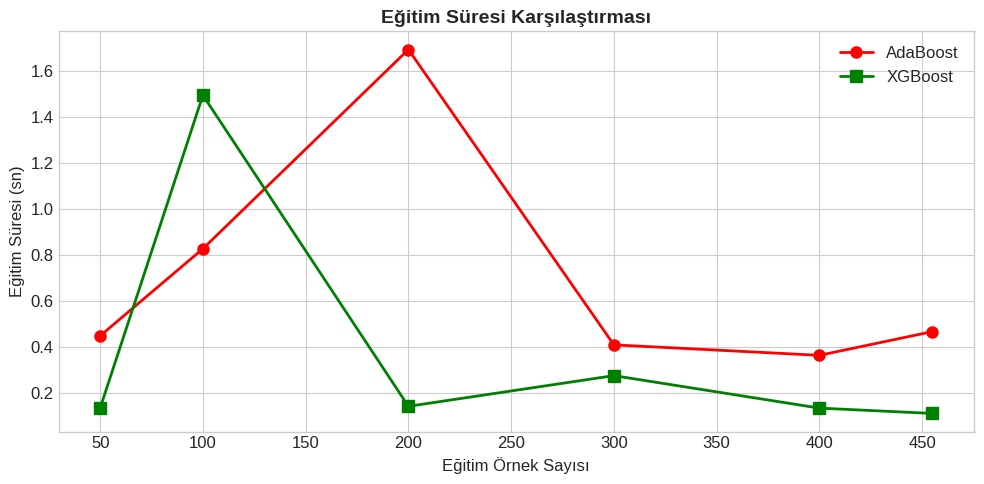


Full dataset eğitim süreleri:
  🔴 AdaBoost : 0.7686 sn
  🟢 XGBoost  : 0.2990 sn


In [ ]:
# Farklı veri boyutlarında eğitim süresi analizi
# Veri büyüdükçe AdaBoost mu, XGBoost mu daha hızlı?

sizes = [50, 100, 200, 300, 400, 455]
ada_times_list = []
xgb_times_list = []

for s in sizes:

    Xs = x_train.iloc[:s]
    ys = y_train.iloc[:s]


    m1 = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=0.1, algorithm='SAMME', random_state=42
    )
    t1 = time.time()
    m1.fit(Xs, ys)
    ada_times_list.append(time.time() - t1)


    m2 = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    t2 = time.time()
    m2.fit(Xs, ys)
    xgb_times_list.append(time.time() - t2)

plt.figure(figsize=(10, 5))
plt.plot(sizes, ada_times_list, 'r-o', markersize=8, linewidth=2, label='AdaBoost')
plt.plot(sizes, xgb_times_list, 'g-s', markersize=8, linewidth=2, label='XGBoost')


plt.xlabel('Eğitim Örnek Sayısı', fontsize=12)
plt.ylabel('Eğitim Süresi (sn)', fontsize=12)
plt.title('Eğitim Süresi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nFull dataset eğitim süreleri:')
print(f'  🔴 AdaBoost : {ada_time:.4f} sn')
print(f'  🟢 XGBoost  : {xgb_time:.4f} sn')

In [ ]:
results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall',
               'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)'],
    'AdaBoost 🔴': [
        f'{ada_acc:.4f}', f'{ada_auc:.4f}', f'{ada_f1:.4f}',
        f'{ada_prec:.4f}', f'{ada_recall:.4f}',
        f'{ada_cv.mean():.4f}', f'{ada_cv.std():.4f}',
        f'{ada_time:.4f}'
    ],
    'XGBoost 🟢': [
        f'{xgb_acc:.4f}', f'{xgb_auc:.4f}', f'{xgb_f1:.4f}',
        f'{xgb_prec:.4f}', f'{xgb_recall:.4f}',
        f'{xgb_cv.mean():.4f}', f'{xgb_cv.std():.4f}',
        f'{xgb_time:.4f}'
    ],
    'Kazanan': [
        '🟢 XGBoost' if xgb_acc    >= ada_acc    else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_auc    >= ada_auc    else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_f1     >= ada_f1     else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_prec   >= ada_prec   else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_recall >= ada_recall else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.mean() >= ada_cv.mean() else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_cv.std()  <= ada_cv.std()  else '🔴 AdaBoost',
        '🟢 XGBoost' if xgb_time <= ada_time else '🔴 AdaBoost'
    ]
})

print('\n' + '='*65)
print('         📊 ADABOOST vs XGBOOST — SONUÇ TABLOSU')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

xgb_wins = sum(1 for k in results_df['Kazanan'] if 'XGBoost' in k)
ada_wins = sum(1 for k in results_df['Kazanan'] if 'AdaBoost' in k)
print(f'\n🏆 GENEL SONUÇ:')
print(f'   🟢 XGBoost kazandı  : {xgb_wins}/{len(results_df)} kategoride')
print(f'   🔴 AdaBoost kazandı : {ada_wins}/{len(results_df)} kategoride')


         📊 ADABOOST vs XGBOOST — SONUÇ TABLOSU
            Metrik AdaBoost 🔴 XGBoost 🟢    Kazanan
          Accuracy     0.8478    0.8478  🟢 XGBoost
           AUC-ROC     0.9128    0.9232  🟢 XGBoost
          F1 Score     0.8667    0.8667  🟢 XGBoost
         Precision     0.8426    0.8426  🟢 XGBoost
            Recall     0.8922    0.8922  🟢 XGBoost
       CV Ortalama     0.7826    0.7391 🔴 AdaBoost
            CV Std     0.1158    0.0880  🟢 XGBoost
Eğitim Süresi (sn)     0.7686    0.2990  🟢 XGBoost

🏆 GENEL SONUÇ:
   🟢 XGBoost kazandı  : 7/8 kategoride
   🔴 AdaBoost kazandı : 1/8 kategoride
